# NIBSS-calibrated synthetic inter-bank fraud dataset: demo notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/otujacob/NIBSS-Fraud-Dataset-Generator---Build-Validation/blob/main/demo.ipynb)

This notebook is a thin wrapper. **All generator logic lives in `generate_dataset.py`**; nothing is re-implemented here, so the notebook cannot drift from the code used in the paper.
It (1) generates the dataset, (2) checks it against NIBSS 2023 totals, (3) re-verifies that the behavioural features are strictly causal, (4) plots the main distributions and (5) runs a small chronological benchmark.

Run all cells top to bottom (about 5 minutes). The validation columns are computed in separate variables and are never added to the feature table.

In [1]:
%pip install -q pyarrow xgboost scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, subprocess
if not os.path.exists('generate_dataset.py'):          # e.g. on Colab: fetch the repo
    subprocess.run(['git', 'clone', '-q', 'https://github.com/otujacob/NIBSS-Fraud-Dataset-Generator---Build-Validation', 'repo'], check=True)
    sys.path.insert(0, 'repo')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import generate_dataset as G

## 1. Generate the dataset
Same call as `python generate_dataset.py --customers 25000 --prevalence 0.001 --seed 42`.

In [3]:
df = G.generate(n_customers=25000, prevalence=0.001, seed=42)
print(f'{len(df):,} rows, {df.is_fraud.sum():,} fraud ({df.is_fraud.mean():.4%})')
print(df.timestamp.min(), '->', df.timestamp.max())
df.head()

2,102,211 rows, 2,094 fraud (0.0996%)
2023-01-01 00:00:32.365918636 -> 2023-12-31 23:59:13.995220423


,transaction_id,customer_id,timestamp,amount,channel,bank,merchant_category,location,age_group,is_fraud,...,online_channel_ratio,velocity_score,merchant_risk_score,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,is_peak_hour
0,TXN000000000,CUST0023742,2023-01-01 00:00:32.365918636,95345.89,Mobile,Bank_7,Restaurant,Rivers,26-35,0,...,0.854545,0.00000,0.463636,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0
1,TXN000000001,CUST0023586,2023-01-01 00:01:03.525371790,38231.36,POS,Bank_9,Airtime,Lagos,26-35,0,...,0.280702,0.00000,0.681818,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0
2,TXN000000002,CUST0009299,2023-01-01 00:02:10.941374779,365428.14,ATM,Bank_10,Restaurant,Lagos,18-25,0,...,0.000000,0.00000,0.463636,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0
3,TXN000000003,CUST0023065,2023-01-01 00:03:10.054853201,128374.52,Mobile,Bank_10,Bill Payment,Lagos,36-45,0,...,1.000000,0.00000,0.754545,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0
4,TXN000000004,CUST0012799,2023-01-01 00:06:21.822129726,117872.06,Mobile,Bank_1,Transfer,Oyo,36-45,0,...,1.000000,0.82577,0.900000,0.0,1.0,-0.781831,0.62349,0.5,0.866025,0


## 2. Fraud channel mix and monthly profile versus NIBSS 2023
Channel and month profiles match NIBSS **by construction** (quotas and weighted sampling); this checks the implementation, not realism.

In [4]:
fr = df[df.is_fraud == 1]
ch_gen = fr.channel.value_counts(normalize=True).reindex(G.CHANNELS)
ch_nib = pd.Series(G.NIBSS_CH_COUNT).reindex(G.CHANNELS); ch_nib = ch_nib / ch_nib.sum()
mo_gen = fr.timestamp.dt.month.value_counts(normalize=True).sort_index()
mo_nib = pd.Series(G.NIBSS_MONTH_COUNT, index=range(1, 13)); mo_nib = mo_nib / mo_nib.sum()
print('max channel deviation (pp):', round(float((ch_gen - ch_nib).abs().max() * 100), 2))
print('max month deviation (pp):  ', round(float((mo_gen - mo_nib).abs().max() * 100), 2))
pd.DataFrame({'generated': ch_gen.round(4), 'NIBSS': ch_nib.round(4)})

max channel deviation (pp): 0.15
max month deviation (pp):   1.15


,generated,NIBSS
ATM,0.0076,0.0076
ECOM,0.0248,0.0256
IB,0.0564,0.0563
Mobile,0.4990,0.4975
POS,0.1834,0.1838
Web,0.2287,0.2291


## 3. Causality check (brute force)
For a random sample of rows, recompute `tx_count_24h`, `amount_vs_mean_ratio` and `velocity_score` directly from that customer's **strictly earlier** transactions and compare with the stored values.
This uses a small run with the burn-in kept (`drop_burnin=False`), because the released file drops burn-in rows, which are the history for early-January transactions.

In [5]:
s = G.generate(n_customers=2000, seed=7, drop_burnin=False).reset_index(drop=True)
s['t'] = s.timestamp.astype('int64') / 1e9
grp = {c: g for c, g in s.groupby('customer_id')}
rng = np.random.default_rng(0); errs = []
for i in rng.choice(len(s), 400, replace=False):
    r = s.loc[i]; g = grp[r.customer_id]
    prior = g[g.index < i]                                   # strictly earlier rows only
    n24 = int(((r.t - prior.t) <= 86400).sum()); s24 = prior.amount[(r.t - prior.t) <= 86400].sum()
    m = prior.amount.mean() if len(prior) else np.nan
    ratio = r.amount / m if len(prior) else 1.0
    vel = n24 * s24 / m if len(prior) else 0.0
    assert n24 == r.tx_count_24h, (i, n24, r.tx_count_24h)
    errs += [abs(ratio - r.amount_vs_mean_ratio) / max(abs(ratio), 1e-9),
             abs(vel - r.velocity_score) / max(abs(vel), 1.0)]
print('24h counts match exactly on 400 rows; max relative error in ratio/velocity: %.1e' % max(errs))

24h counts match exactly on 400 rows; max relative error in ratio/velocity: 2.8e-06


## 4. Distributions

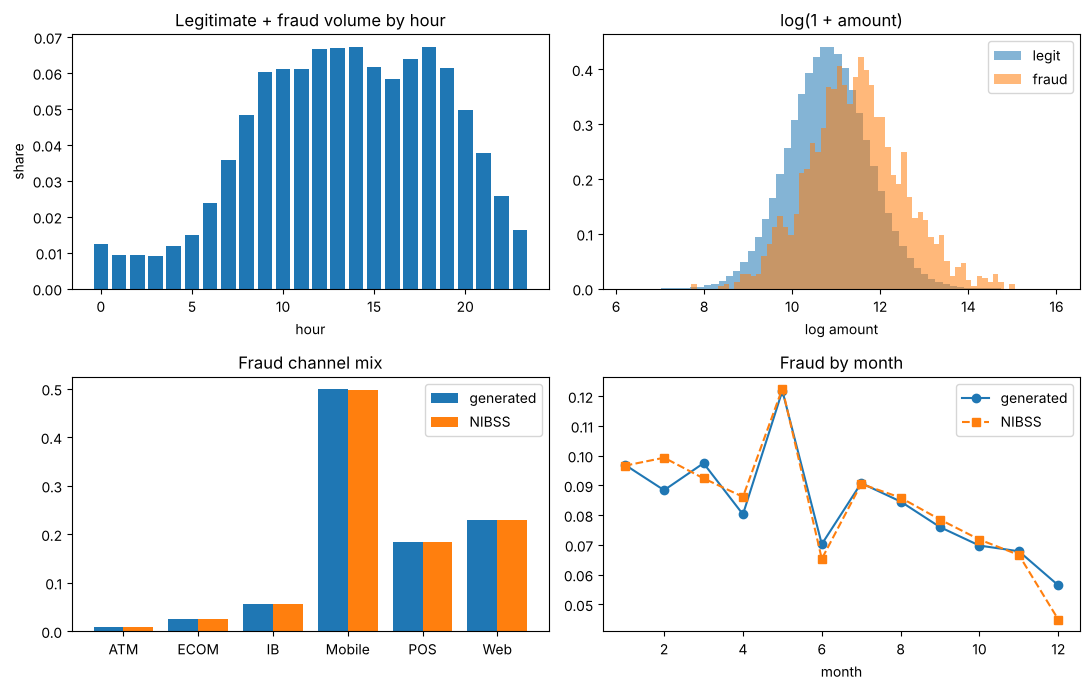

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
h = df.groupby(df.timestamp.dt.hour).size(); ax[0,0].bar(h.index, h.values / h.sum()); ax[0,0].set(title='Legitimate + fraud volume by hour', xlabel='hour', ylabel='share')
for lab, d in df.groupby('is_fraud'):
    ax[0,1].hist(d.amount_log, bins=60, density=True, alpha=.55, label='fraud' if lab else 'legit')
ax[0,1].set(title='log(1 + amount)', xlabel='log amount'); ax[0,1].legend()
x = np.arange(6); ax[1,0].bar(x - .2, ch_gen.values, .4, label='generated'); ax[1,0].bar(x + .2, ch_nib.values, .4, label='NIBSS')
ax[1,0].set_xticks(x, G.CHANNELS); ax[1,0].set(title='Fraud channel mix'); ax[1,0].legend()
ax[1,1].plot(mo_gen.index, mo_gen.values, 'o-', label='generated'); ax[1,1].plot(mo_nib.index, mo_nib.values, 's--', label='NIBSS')
ax[1,1].set(title='Fraud by month', xlabel='month'); ax[1,1].legend()
plt.tight_layout(); plt.show()

## 5. Chronological benchmark
Split: first 60% of time = train, next 20% = validation, last 20% = test. Class weighting is used, and metrics are threshold-free (PR-AUC, recall at 1% false-positive rate, precision in the top 1% of scores).
`tx_count_total` is dropped here because history length drifts through the year (see the Limitations section of the paper). The full benchmark with bootstrap intervals is `compare.py`.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_curve
import xgboost as xgb

CAT = ['channel', 'merchant_category', 'bank', 'location', 'age_group']
DROP = ['transaction_id', 'customer_id', 'timestamp', 'is_fraud', 'fraud_technique', 'tx_count_total']
X = pd.get_dummies(df.drop(columns=DROP), columns=CAT).astype(float).values; y = df.is_fraud.values
ti = df.timestamp.astype('int64').values; q1, q2 = np.quantile(ti, [.6, .8])
tr, te = ti < q1, ti >= q2
rng = np.random.default_rng(0)
neg = rng.choice(np.flatnonzero(tr & (y == 0)), 300_000, replace=False)
idx = np.r_[np.flatnonzero(tr & (y == 1)), neg]
sc = StandardScaler().fit(X[idx])
models = {'Logistic regression': LogisticRegression(class_weight='balanced', max_iter=2000),
          'Random forest': RandomForestClassifier(200, min_samples_leaf=5, class_weight='balanced_subsample', n_jobs=-1, random_state=0),
          'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=.05, subsample=.8, colsample_bytree=.8, scale_pos_weight=50, n_jobs=-1, random_state=0)}
rows = []
for name, m in models.items():
    if name == 'Logistic regression':
        m.fit(sc.transform(X[idx]), y[idx]); p = m.predict_proba(sc.transform(X[te]))[:, 1]
    else:
        m.fit(X[idx], y[idx]); p = m.predict_proba(X[te])[:, 1]
    fpr, tpr, _ = roc_curve(y[te], p)
    top = np.argsort(-p)[: int(.01 * te.sum())]
    rows.append({'model': name, 'PR-AUC': average_precision_score(y[te], p),
                 'recall@1%FPR': np.interp(.01, fpr, tpr), 'precision top 1%': y[te][top].mean()})
print(f'test: {te.sum():,} rows, {y[te].sum()} fraud, random PR-AUC = {y[te].mean():.4f}')
pd.DataFrame(rows).round(3).set_index('model')

test: 420,443 rows, 308 fraud, random PR-AUC = 0.0007


,PR-AUC,recall@1%FPR,precision top 1%
model,,,
Logistic regression,0.032,0.256,0.019
Random forest,0.067,0.299,0.022
XGBoost,0.055,0.256,0.019


Results should be close to the paper's Table (PR-AUC 0.03 to 0.07, recall at 1% FPR about 0.26 to 0.31). Small differences are expected because this uses fewer trees and no validation-chosen threshold.